In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/superstore_clean.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_quantity = df["Quantity"].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Units Sold: {total_quantity:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Total Units Sold: 37,873


In [3]:
profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


In [4]:
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


Matplotlib is building the font cache; this may take a moment.


NameError: name 'plt' is not defined

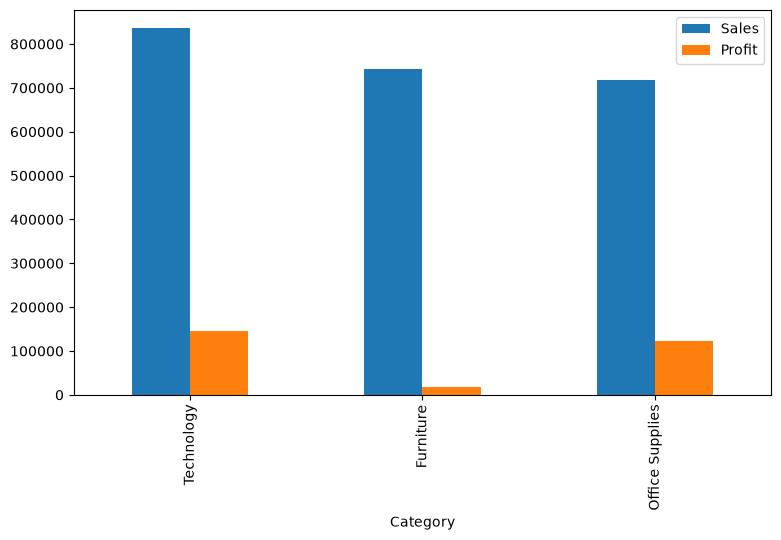

In [5]:
category_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
category_summary.round(2)

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80


In [7]:
subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

subcategory_summary.round(2)

,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Appliances,107532.16,18138.01
Furnishings,91705.16,13059.14


NameError: name 'plt' is not defined

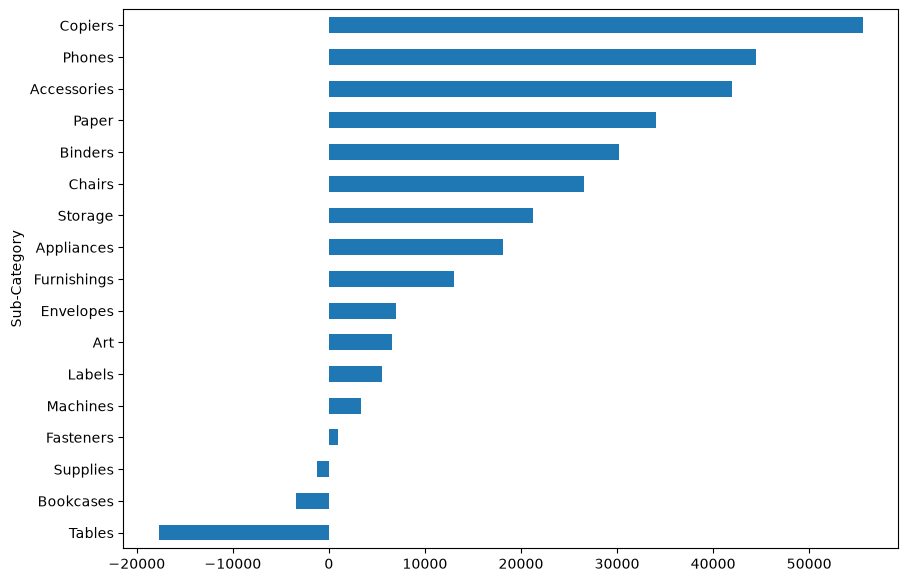

In [8]:
subcategory_summary["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [9]:
discount_summary = (
    df.groupby("Discount")[["Sales", "Profit"]]
      .agg(["sum", "mean"])
)

discount_summary.round(2)

Sales             Profit        
                 sum    mean        sum    mean
Discount                                       
0.00      1087908.47  226.74  320987.60   66.90
0.10        54369.35  578.40    9029.18   96.06
0.15        27558.52  529.97    1418.99   27.29
0.20       764594.37  209.08   90337.31   24.70
0.30       103226.66  454.74  -10369.28  -45.68
0.32        14493.46  536.79   -2391.14  -88.56
0.40       116417.78  565.13  -23057.05 -111.93
0.45         5484.97  498.63   -2493.11 -226.65
0.50        58918.54  892.71  -20506.43 -310.70
0.60         6644.70   48.15   -5944.66  -43.08
0.70        40620.28   97.18  -40075.36  -95.87
0.80        16963.76   56.55  -30539.04 -101.80

NameError: name 'plt' is not defined

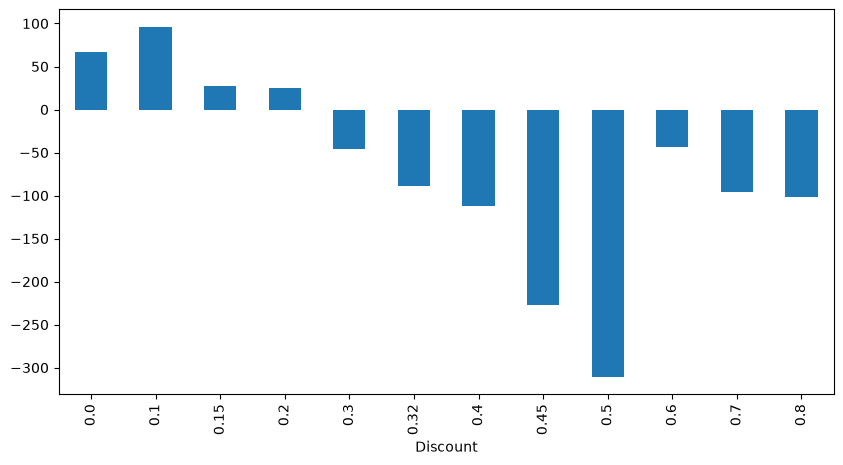

In [10]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
yearly_summary = (
    df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]]
      .sum()
)

yearly_summary.round(2)

,Sales,Profit
Order Date,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


NameError: name 'plt' is not defined

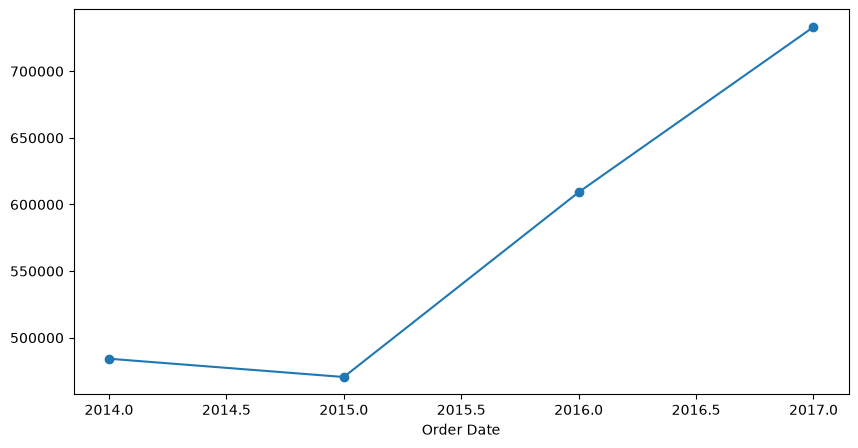

In [12]:
yearly_summary["Sales"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

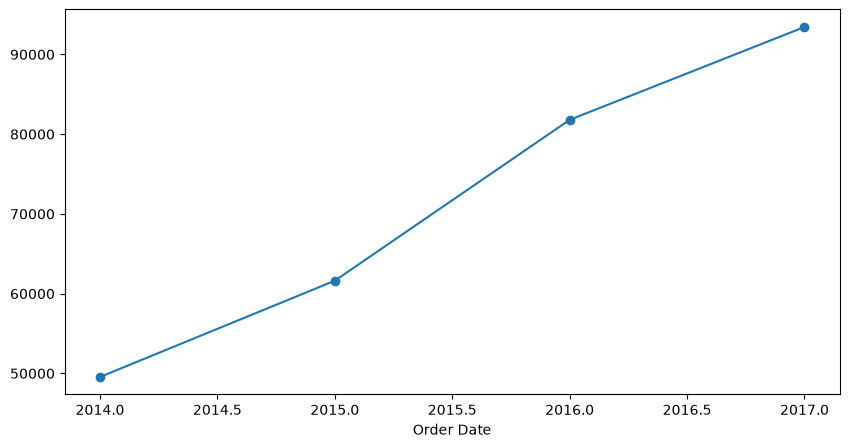

In [13]:
yearly_summary["Profit"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Annual Profit Trend")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

region_summary.round(2)

,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
South,391721.90,46749.43
Central,501239.89,39706.36


NameError: name 'plt' is not defined

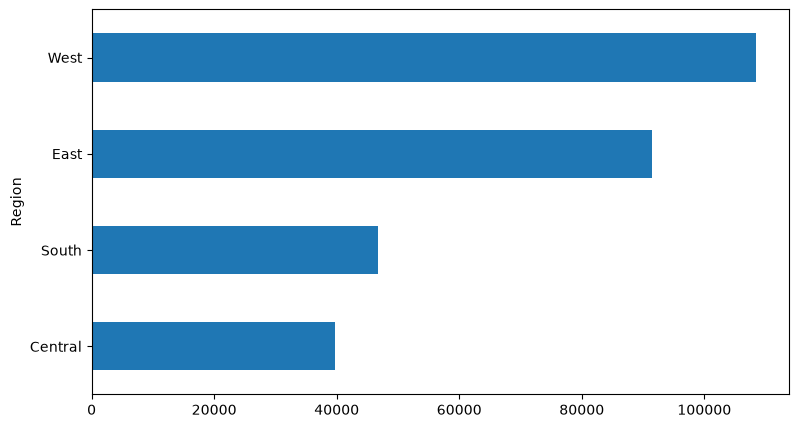

In [15]:
region_summary["Profit"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Profit by Region")
plt.xlabel("Profit ($)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [16]:
state_summary = (
    df.groupby("State")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

state_summary.head(10).round(2)

,Sales,Profit
State,,
California,457687.63,76381.39
New York,310876.27,74038.55
Washington,138641.27,33402.65
Michigan,76269.61,24463.19
Virginia,70636.72,18597.95
Indiana,53555.36,18382.94
Georgia,49095.84,16250.04
Kentucky,36591.75,11199.70
Minnesota,29863.15,10823.19


In [17]:
state_summary.tail(10).round(2)

,Sales,Profit
State,,
Oregon,17431.15,-1190.47
Florida,89473.71,-3399.30
Arizona,35282.00,-3427.92
Tennessee,30661.87,-5341.69
Colorado,32108.12,-6527.86
North Carolina,55603.16,-7490.91
Illinois,80166.10,-12607.89
Pennsylvania,116511.91,-15559.96
Ohio,78258.14,-16971.38


In [18]:
segment_summary = (
    df.groupby("Segment")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

segment_summary.round(2)

,Sales,Profit
Segment,,
Consumer,1161401.34,134119.21
Corporate,706146.37,91979.13
Home Office,429653.15,60298.68


NameError: name 'plt' is not defined

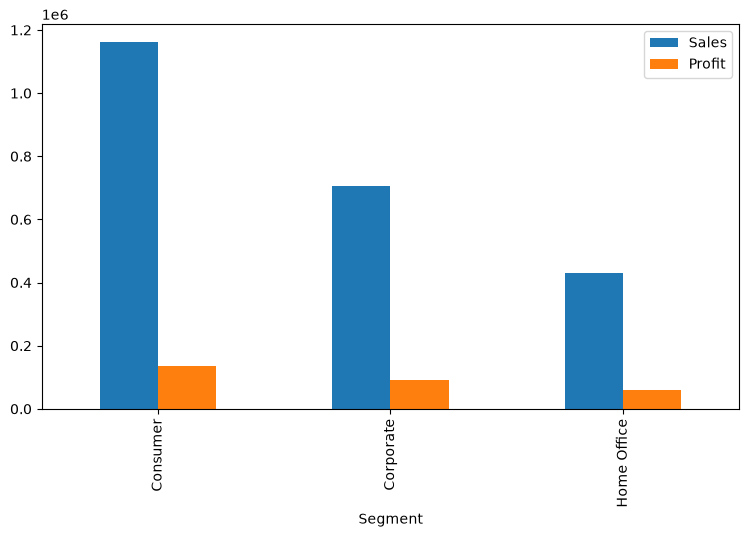

In [19]:
segment_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
segment_summary["Profit Margin (%)"] = (
    segment_summary["Profit"] / segment_summary["Sales"] * 100
)

segment_summary.round(2)

,Sales,Profit,Profit Margin (%)
Segment,,,
Consumer,1161401.34,134119.21,11.55
Corporate,706146.37,91979.13,13.03
Home Office,429653.15,60298.68,14.03


In [21]:
product_summary = (
    df.groupby("Product Name")[["Sales", "Profit", "Quantity"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

product_summary.head(10).round(2)

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
Canon PC1060 Personal Laser Copier,11619.83,4570.93,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,24
Ibico EPK-21 Electric Binding System,15875.92,3345.28,13


In [22]:
product_summary.tail(10).round(2)

,Sales,Profit,Quantity
Product Name,,,
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.25,-1148.44,15
Balt Solid Wood Round Tables,6518.75,-1201.06,19
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18


NameError: name 'plt' is not defined

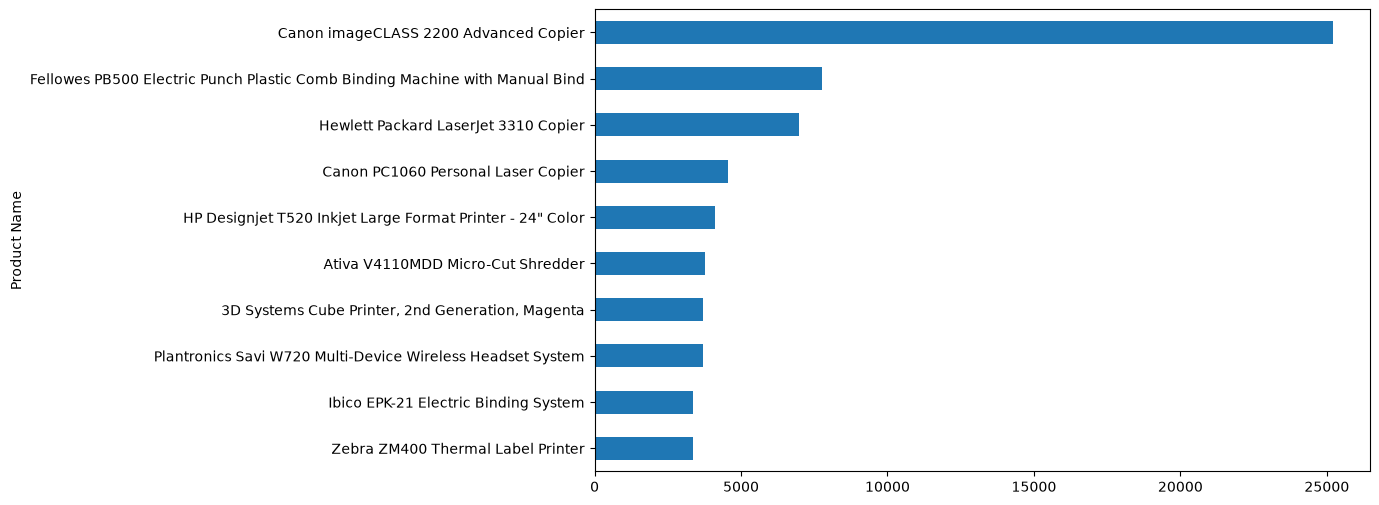

In [23]:
product_summary["Profit"].head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

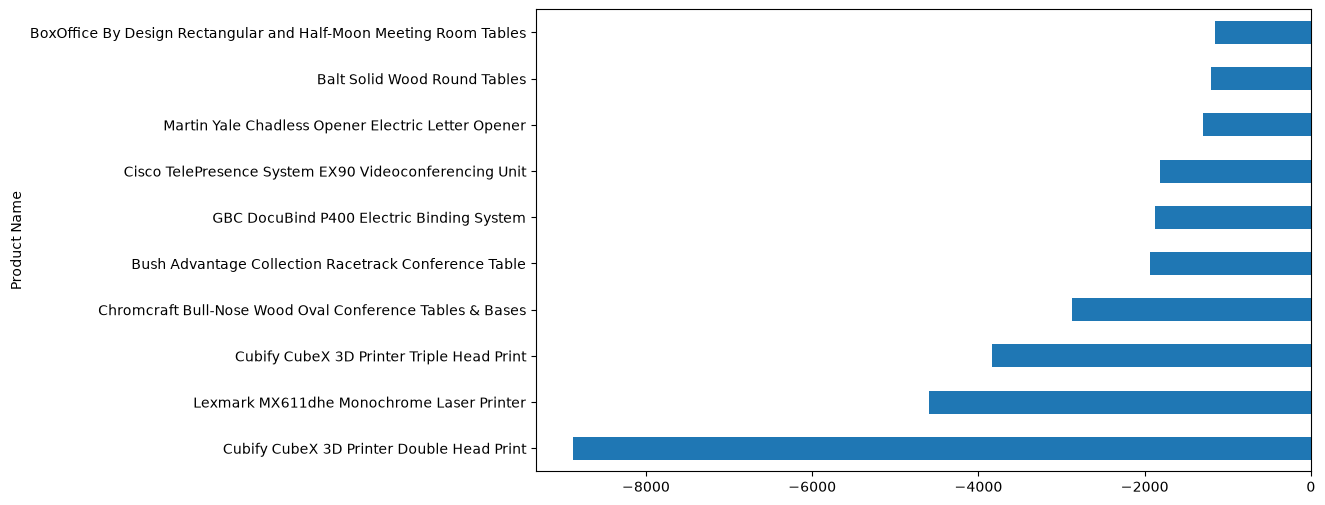

In [24]:
product_summary["Profit"].tail(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [25]:
monthly_summary = (
    df.groupby(df["Order Date"].dt.month)[["Sales", "Profit"]]
      .sum()
)

monthly_summary.round(2)

,Sales,Profit
Order Date,,
1,94924.84,9134.45
2,59751.25,10294.61
3,205005.49,28594.69
4,137762.13,11587.44
5,155028.81,22411.31
6,152718.68,21285.80
7,147238.10,13832.66
8,159044.06,21776.94
9,307649.95,36857.48


In [26]:
monthly_summary.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_summary

,Sales,Profit
Jan,94924.8356,9134.4461
Feb,59751.2514,10294.6107
Mar,205005.4888,28594.6872
Apr,137762.1286,11587.4363
May,155028.8117,22411.3078
Jun,152718.6793,21285.7954
Jul,147238.0970,13832.6648
Aug,159044.0630,21776.9384
Sep,307649.9457,36857.4753
Oct,200322.9847,31784.0413


NameError: name 'plt' is not defined

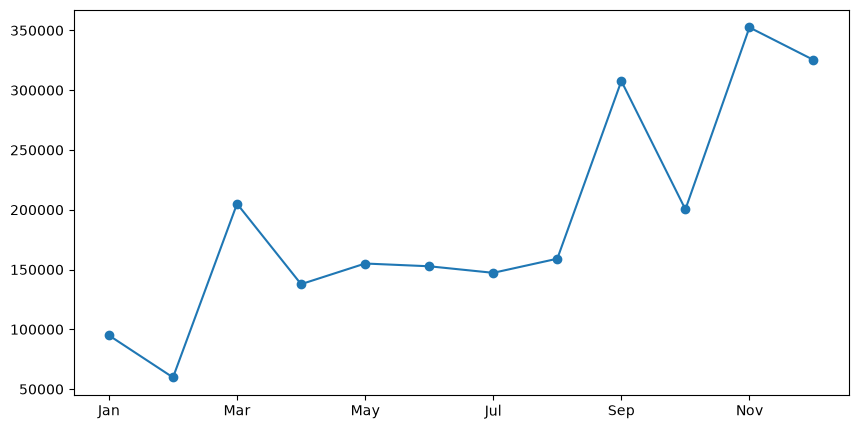

In [27]:
monthly_summary["Sales"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

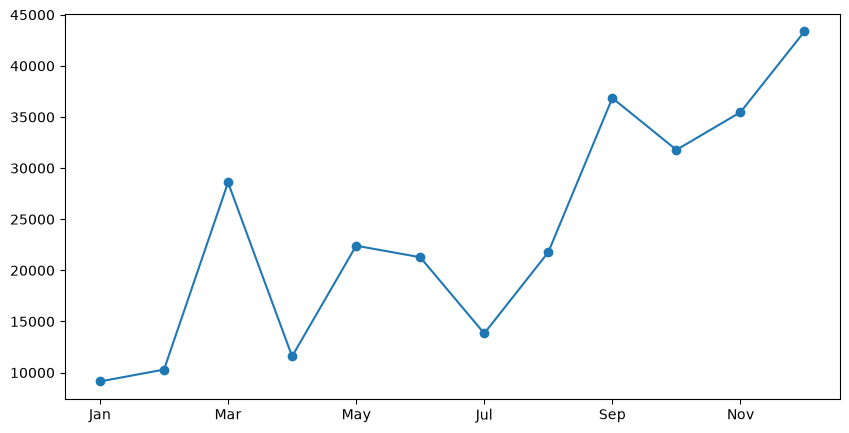

In [28]:
monthly_summary["Profit"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Monthly Profit Pattern")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

In [29]:
shipping_summary = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
      .agg(["sum", "mean"])
)

shipping_summary.round(2)

Sales             Profit       
                       sum    mean        sum   mean
Ship Mode                                           
First Class      351428.42  228.50   48969.84  31.84
Same Day         128363.12  236.40   15891.76  29.27
Second Class     459193.57  236.09   57446.64  29.54
Standard Class  1358215.74  227.58  164088.79  27.49

NameError: name 'plt' is not defined

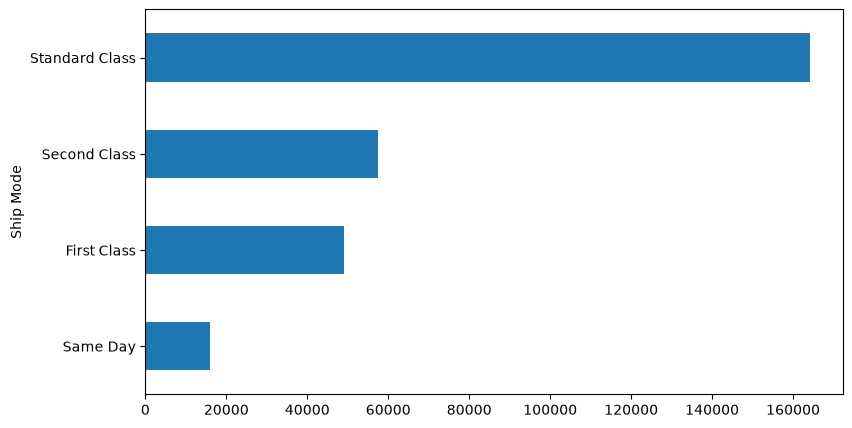

In [30]:
shipping_profit = df.groupby("Ship Mode")["Profit"].sum().sort_values()

shipping_profit.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Total Profit by Shipping Mode")
plt.xlabel("Profit ($)")
plt.ylabel("Shipping Mode")
plt.tight_layout()
plt.show()

In [31]:
order_value = (
    df.groupby("Ship Mode")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

order_value.round(2)

Ship Mode
Same Day          236.40
Second Class      236.09
First Class       228.50
Standard Class    227.58
Name: Sales, dtype: float64

In [32]:
import matplotlib.pyplot as plt

In [33]:
category_summary.sort_values("Profit", ascending=False).round(2)

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Office Supplies,719047.03,122490.80
Furniture,741999.80,18451.27


In [34]:
print("TOP 5")
display(subcategory_summary.head(5).round(2))

print("\nBOTTOM 5")
display(subcategory_summary.tail(5).round(2))

TOP 5


,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76



BOTTOM 5


,Sales,Profit
Sub-Category,,
Machines,189238.63,3384.76
Fasteners,3024.28,949.52
Supplies,46673.54,-1189.10
Bookcases,114880.00,-3472.56
Tables,206965.53,-17725.48


In [35]:
discount_profit = df.groupby("Discount")["Profit"].agg(["sum", "mean", "count"])
discount_profit.round(2)

,sum,mean,count
Discount,,,
0.00,320987.60,66.90,4798
0.10,9029.18,96.06,94
0.15,1418.99,27.29,52
0.20,90337.31,24.70,3657
0.30,-10369.28,-45.68,227
0.32,-2391.14,-88.56,27
0.40,-23057.05,-111.93,206
0.45,-2493.11,-226.65,11
0.50,-20506.43,-310.70,66


In [36]:
print("TOP 10 STATES")
display(state_summary.head(10).round(2))

print("\nBOTTOM 10 STATES")
display(state_summary.tail(10).round(2))

TOP 10 STATES


,Sales,Profit
State,,
California,457687.63,76381.39
New York,310876.27,74038.55
Washington,138641.27,33402.65
Michigan,76269.61,24463.19
Virginia,70636.72,18597.95
Indiana,53555.36,18382.94
Georgia,49095.84,16250.04
Kentucky,36591.75,11199.70
Minnesota,29863.15,10823.19



BOTTOM 10 STATES


,Sales,Profit
State,,
Oregon,17431.15,-1190.47
Florida,89473.71,-3399.30
Arizona,35282.00,-3427.92
Tennessee,30661.87,-5341.69
Colorado,32108.12,-6527.86
North Carolina,55603.16,-7490.91
Illinois,80166.10,-12607.89
Pennsylvania,116511.91,-15559.96
Ohio,78258.14,-16971.38


In [37]:
print("TOP 10 PRODUCTS")
display(product_summary.head(10).round(2))

print("\nBOTTOM 10 PRODUCTS")
display(product_summary.tail(10).round(2))

TOP 10 PRODUCTS


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
Canon PC1060 Personal Laser Copier,11619.83,4570.93,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,24
Ibico EPK-21 Electric Binding System,15875.92,3345.28,13



BOTTOM 10 PRODUCTS


,Sales,Profit,Quantity
Product Name,,,
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.25,-1148.44,15
Balt Solid Wood Round Tables,6518.75,-1201.06,19
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18


In [38]:
segment_summary.round(2)

,Sales,Profit,Profit Margin (%)
Segment,,,
Consumer,1161401.34,134119.21,11.55
Corporate,706146.37,91979.13,13.03
Home Office,429653.15,60298.68,14.03


In [39]:
print("=== CATEGORY ===")
display(category_summary.round(2))

print("\n=== SUB-CATEGORY ===")
display(subcategory_summary.round(2))

print("\n=== DISCOUNT ===")
display(discount_profit.round(2))

print("\n=== SEGMENTS ===")
display(segment_summary.round(2))

print("\n=== REGIONS ===")
display(region_summary.round(2))

print("\n=== TOP PRODUCTS ===")
display(product_summary.head(10).round(2))

print("\n=== BOTTOM PRODUCTS ===")
display(product_summary.tail(10).round(2))

print("\n=== YEARLY ===")
display(yearly_summary.round(2))

=== CATEGORY ===


,Sales,Profit
Category,,
Technology,836154.03,145454.95
Furniture,741999.80,18451.27
Office Supplies,719047.03,122490.80



=== SUB-CATEGORY ===


,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Appliances,107532.16,18138.01
Furnishings,91705.16,13059.14



=== DISCOUNT ===


...

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
Canon PC1060 Personal Laser Copier,11619.83,4570.93,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,24
Ibico EPK-21 Electric Binding System,15875.92,3345.28,13



=== BOTTOM PRODUCTS ===


,Sales,Profit,Quantity
Product Name,,,
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.25,-1148.44,15
Balt Solid Wood Round Tables,6518.75,-1201.06,19
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18



=== YEARLY ===


,Sales,Profit
Order Date,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


In [40]:
df.to_csv("../data/processed/superstore_clean.csv", index=False)